In [ ]:
# --timeframe 1d   : Таймфрейм свечей (дневные данные).
# --start-year 2000: Глубина загрузки истории (начиная с 2000 года).
# --workers 6      : Количество параллельных потоков для ускорения загрузки.

!python -m _tools.update_market_data --timeframe 1d --start-year 2000 --workers 18
!python -m _tools.update_macro --timeframe 1d --start-year 2000 --workers 18
# Выполняет комплексную проверку целостности, отсутствия пропусков и корректности OHLCV данных.
!python -m _tools.check_data_quality

In [ ]:
!bash start_data_swarm.sh

In [ ]:
!bash stop_data_swarm.sh

In [ ]:
!python -m _tools.check_and_heal_data

In [ ]:
#полная проверка подготовленных на предыдущем этапе данных
!python -m _tools.verify_data

In [ ]:
#Запуск нескольких процессов в параллели
!bash start_swarm.sh \
    --dataset_dir "data/processed/2000_2026_1d_18_3" \
    --bonus_ratio 0.2 \
    --min_delta 0.001 \
    --runs 400 --epochs 100 \
    --lr 2e-3 --l2_reg 1e-5 \
    --start_fold "fold_2013" \
    --factor 0.5 --patience 3 \
    --vram 10000/8 --stagger 0 \
    --keep 5 \
    --append \
    --arch mlp
    #--arch cnn, conv1d+gru, mlp, attention
    #--track_trajectory
    #--init_pca_coord -148.0 -116.0 --init_pca_radius 20.0 \

In [1]:
!./stop_swarm.sh
!python -m _tools.clean_lstm_models --keep 5

In [ ]:
#python run_all_ensembles.py --dataset_dir "data/processed/2000_2026_1d_10_1" --max_k 20
import os
from pathlib import Path
DATASET_DIR = "data/processed/2000_2026_1d_5_10"
MAX_K = 20
folds = sorted([d.name for d in Path(DATASET_DIR).glob("fold_*") if d.is_dir()])
print(f"🔍 Найдено фолдов: {len(folds)} в конфигурации {DATASET_DIR}\n")
for fold in folds:
    print("\n" + "="*80)
    print(f"🚀 ЗАПУСК АНСАМБЛИРОВАНИЯ: {fold}")
    print("="*80)
    !python -m _tools.ensemble_predictor --dataset_dir {DATASET_DIR} --fold {fold} --max_k {MAX_K}

In [ ]:
%run _tools/plot_landscape.py --fold data/processed/2000_2026_1d_30_5/fold_2014

In [ ]:
%matplotlib inline
%run _tools/analyze_runs.py data/processed/2000_2026_1d_3_1/fold_2026 --runs 100 --arch attention

In [ ]:
!python -m _tools.prepare_rl_env

In [ ]:
!python -m _tools.check_env_data

In [ ]:
!python -m _tools.train_rllib_pbt --population 6 --iterations 300 --force
#--cpu

In [ ]:
# Запуск отчета
report = generate_report("data/processed")
display(report)

In [ ]:
%load_ext tensorboard
%tensorboard --logdir data/processed/2000_2026_1d/rl_env/ray_results/pbt_trading_bot

In [34]:
from pathlib import Path

def print_tree(directory, prefix=""):
    """Рекурсивный вывод структуры папок и файлов"""
    dir_path = Path(directory)
    if not dir_path.exists():
        print(f"❌ Путь не найден: {directory}")
        return

    # Получаем список всех элементов и сортируем
    items = sorted(list(dir_path.iterdir()), key=lambda x: (not x.is_dir(), x.name))
    
    for i, item in enumerate(items):
        is_last = (i == len(items) - 1)
        connector = "└── " if is_last else "├── "
        
        print(f"{prefix}{connector}{item.name}")
        
        if item.is_dir():
            # Если это папка, заходим в неё (но ограничиваем глубину для чистоты, если нужно)
            extension = "    " if is_last else "│   "
            print_tree(item, prefix + extension)

# Путь к папке
target_path = "/home/restorator/trader_test/data/processed/2000_2026_1d/rl_env"

print(f"🌲 Структура проекта для: {target_path}")
print_tree(target_path)

🌲 Структура проекта для: /home/restorator/trader_test/data/processed/2000_2026_1d/rl_env
├── champions
│   ├── fold_2010_c10_cnn_loss_0.8462_acc_70.92_run_s_03_194634_3d4714.keras
│   ├── fold_2010_c10_conv1d+gru_loss_0.8331_acc_69.53_run_s_01_203728_d0f880.keras
│   ├── fold_2010_c18_attention_loss_0.9249_acc_65.39_run_s_09_230321_cf9fae.keras
│   ├── fold_2010_c18_cnn_loss_0.9059_acc_66.45_run_s_08_071344_8b0bd8.keras
│   ├── fold_2010_c18_cnn_loss_0.9087_acc_66.28_run_s_08_071344_7b9350.keras
│   ├── fold_2010_c18_conv1d+gru_loss_0.8892_acc_66.39_run_s_08_235228_c58866.keras
│   ├── fold_2010_c18_conv1d+gru_loss_0.8954_acc_66.41_run_s_08_235228_658f36.keras
│   ├── fold_2010_c18_conv1d+gru_loss_0.8964_acc_66.73_run_s_08_235228_40b693.keras
│   ├── fold_2010_c18_conv1d+gru_loss_0.8970_acc_65.72_run_s_08_235228_40dbce.keras
│   ├── fold_2010_c18_conv1d+gru_loss_0.8992_acc_65.31_run_s_08_235228_47b87d.keras
│   ├── fold_2010_c3_mlp_loss_0.8784_acc_69.46_run_manual_a9f055.keras
│   ├── 

Парсим лог и сохраняем чистый summary_report (без params)...
✓ Чистый фильтрованный лог сохранен в: /home/restorator/trader_test/summary_report.txt



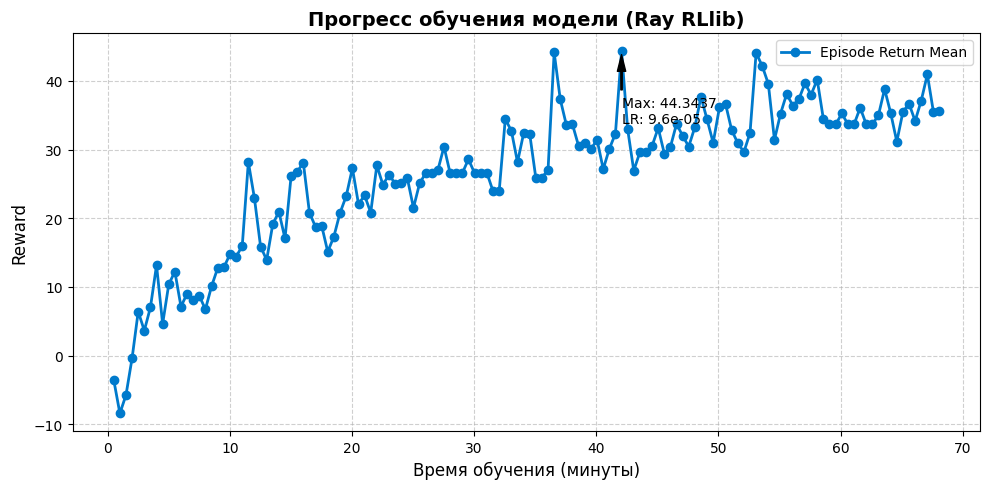

📊 Топ-5 результатов:
   time_raw    trial_id    reward       lr
   42min 4s d53e9_00001 44.343735 0.000096
  36min 33s d53e9_00002 44.136728 0.000100
   53min 5s d53e9_00000 44.077374 0.000080
  53min 35s d53e9_00000 42.162028 0.000080
1hr 7min 6s d53e9_00005 40.924179 0.000144


In [3]:
import re
import pandas as pd
import matplotlib.pyplot as plt

input_path = '/home/restorator/trader_test/report.txt'
output_path = '/home/restorator/trader_test/summary_report.txt'

parsed_data = []
total_time_str = "0s"
last_known_lr = 0.0  # Запоминалка на случай обрыва строки

print("Парсим лог и сохраняем чистый summary_report (без params)...")

with open(input_path, 'r', encoding='utf-8') as f_in, \
     open(output_path, 'w', encoding='utf-8') as f_out:
    
    for line in f_in:
        # 1. Ловим и записываем время (тут всё чисто)
        if "Current time:" in line:
            f_out.write(line)
            time_match = re.search(r"Total running time:\s*(.*)", line)
            if time_match:
                total_time_str = time_match.group(1).strip()
            continue
            
        # 2. Ловим метрики лучшего триала
        if "Current best trial:" in line:
            # Сначала вытаскиваем LR из ПОЛНОЙ строки, пока не удалили params
            lr_match = re.search(r"'lr':\s*([0-9\.e-]+)", line)
            if lr_match:
                last_known_lr = float(lr_match.group(1))
            
            # Отрезаем всё лишнее начиная с " and params=" для сохранения в файл
            if " and params=" in line:
                clean_line = line.split(" and params=")[0].strip() + "\n"
            else:
                clean_line = line # Если строка и так была оборвана
                
            f_out.write(clean_line)
            
            # Парсим ID и Reward для графика
            trial_match = re.search(r"Current best trial:\s*([\w_]+)\s+with\s+[\w_/]+=([0-9\.-]+)", line)
            if trial_match:
                trial_id = trial_match.group(1)
                reward = float(trial_match.group(2))
                
                parsed_data.append({
                    "time_raw": total_time_str,
                    "trial_id": trial_id,
                    "reward": reward,
                    "lr": last_known_lr
                })

print(f"✓ Чистый фильтрованный лог сохранен в: {output_path}\n")

# 3. График и статистика (остаются без изменений)
if parsed_data:
    df = pd.DataFrame(parsed_data)
    
    def to_minutes(t_str):
        seconds = 0
        hr_match = re.search(r'(\d+)\s*hr', t_str)
        min_match = re.search(r'(\d+)\s*min', t_str)
        sec_match = re.search(r'(\d+)\s*s', t_str)
        
        if hr_match: seconds += int(hr_match.group(1)) * 3600
        if min_match: seconds += int(min_match.group(1)) * 60
        if sec_match: seconds += int(sec_match.group(1))
        return seconds / 60.0

    df['minutes'] = df['time_raw'].apply(to_minutes)
    df = df.drop_duplicates(subset=['minutes', 'reward'])
    
    plt.figure(figsize=(10, 5))
    plt.plot(df['minutes'], df['reward'], marker='o', color='#007acc', linewidth=2, label='Episode Return Mean')
    plt.title('Прогресс обучения модели (Ray RLlib)', fontsize=14, fontweight='bold')
    plt.xlabel('Время обучения (минуты)', fontsize=12)
    plt.ylabel('Reward', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    best_idx = df['reward'].idxmax()
    best_row = df.loc[best_idx]
    plt.annotate(f"Max: {best_row['reward']:.4f}\nLR: {best_row['lr']}",
                 xy=(best_row['minutes'], best_row['reward']),
                 xytext=(best_row['minutes'], best_row['reward'] - (df['reward'].max() - df['reward'].min())*0.2),
                 arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6))
    
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    print("📊 Топ-5 результатов:")
    print(df.sort_values(by='reward', ascending=False).drop_duplicates(subset=['reward']).head(5)[['time_raw', 'trial_id', 'reward', 'lr']].to_string(index=False))

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ray.rllib.algorithms.algorithm import Algorithm
# Импортируем твою среду из папки инструментов
from _tools.rl_env import TradingEnv 

# =====================================================================
# 1. НАСТРОЙКА ПУТЕЙ (Укажи точный номер финального чекпоинта)
# =====================================================================
# Найди в этой папке точное имя папки триала d53e9_00005 и номер чекпоинта
TRIAL_DIR = "PPO_TradingEnv-v0_d53e9_00005_5_2026-06-10_10-27-27" 
CHECKPOINT_NUM = "checkpoint_000006" # или твой последний сохраненный номер папки

CHECKPOINT_PATH = f"/home/restorator/trader_test/data/processed/2000_2026_1d/rl_env/ray_results/pbt_trading_bot/{TRIAL_DIR}/{CHECKPOINT_NUM}"

# =====================================================================
# 2. ЗАГРУЗКА АГЕНТА И ТЕСТОВОЙ СРЕДЫ
# =====================================================================
import ray
from ray.tune.registry import register_env

# 1. Сначала инициализируем контекст Ray (если он еще не поднят)
ray.init(ignore_reinit_error=True)

# 2. Создаем и жестко регистрируем фабрику среды для всех будущих воркеров
def env_creator(cfg):
    return TradingEnv(cfg)

register_env("TradingEnv-v0", env_creator)

print("⏳ Загрузка обученного RL-агента...")
# 3. Теперь восстанавливаем алгоритм — воркеры увидят окружение в реестре!
algo = Algorithm.from_checkpoint(CHECKPOINT_PATH)

# Конфигурируем среду строго на режим ЭКЗАМЕНА (split_mode='test')
env_config = {
    'data_path': '/home/restorator/trader_test/data/processed/2000_2026_1d/rl_env/environment_data.parquet',
    'split_mode': 'test',  # Переключаемся на период 2022-2026!
    'commission': 0.0003,
    'initial_balance': 100000.0,
    'max_episode_steps': 1500  # Достаточный запас для прогона всего теста
}
env = TradingEnv(env_config)

# =====================================================================
# 3. ЗАПУСК ИМИТАЦИИ ТОРГОВЛИ (ROLLOUT)
# =====================================================================
print("🚀 Запуск симуляции торгового робота на исторических данных...")
obs, info = env.reset()
done = False
truncated = False

# Сборщики метрик для графика
history = {
    'balance': [],
    'price': [],
    'action': [],
    'dates': []
}

while not (done or truncated):
    # Агент принимает решение на основе текущего состояния (без случайных мутаций)
    action = algo.compute_single_action(obs, explore=False)
    
    # Записываем состояние ДО шага
    history['balance'].append(env.balance)
    history['action'].append(action)
    
    # Пытаемся вытащить реальную цену и дату из датасета внутри среды
    if hasattr(env, 'df') and hasattr(env, 'current_step'):
        current_row = env.df.iloc[env.current_step]
        history['price'].append(current_row.get('close', current_row.get('price', 1.0)))
        history['dates'].append(current_row.get('datetime', env.current_step))
    else:
        history['price'].append(1.0)
        history['dates'].append(len(history['balance']))
        
    # Делаем шаг в среде
    obs, reward, done, truncated, info = env.step(action)

# Сохраняем финальную точку
history['balance'].append(env.balance)
history['action'].append(0)
if hasattr(env, 'df') and hasattr(env, 'current_step'):
    current_row = env.df.iloc[min(env.current_step, len(env.df)-1)]
    history['price'].append(current_row.get('close', current_row.get('price', 1.0)))
    history['dates'].append(current_row.get('datetime', env.current_step))
else:
    history['price'].append(1.0)
    history['dates'].append(len(history['balance']))

print(f"🏁 Тест завершен!")
print(f"💰 Начальный баланс: {env_config['initial_balance']:,} руб.")
print(f"📈 Финальный баланс:  {env.balance:,.2f} руб.")
print(f"📊 Чистый профит:     {((env.balance / env_config['initial_balance']) - 1) * 100:.2f}%")

# =====================================================================
# 4. ПОСТРОЕНИЕ ГРАФИКОВ
# =====================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# График 1: Кривая капитала (Equity Curve)
dates_balance = history['dates'] if len(history['dates']) == len(history['balance']) else history['dates'][:-1]
ax1.plot(dates_balance, history['balance'][:len(dates_balance)], color='#1f77b4', linewidth=2, label='Баланс счета (Equity)')
ax1.axhline(y=env_config['initial_balance'], color='red', linestyle='--', alpha=0.5, label='Стартовый капитал')
ax1.set_title('Кривая капитала агента (Период жесткого теста: 2022–2026)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Капитал (руб.)', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper left')

# График 2: Точки входа и выхода из позиций
dates_price = history['dates'][:-1]
prices = history['price'][:-1]
actions = np.array(history['action'][:-1])

ax2.plot(dates_price, prices, color='#7f7f7f', alpha=0.5, linewidth=1.5, label='Цена базового актива')

# --- ВНИМАНИЕ: Подставь сюда соответствие индексов действий из своей rl_env.py ---
# Например: 0 = Hold, 1 = Buy, 2 = Sell (или Long/Short)
BUY_ACTION_IDX = 1  
SELL_ACTION_IDX = 2 

buy_mask = (actions == BUY_ACTION_IDX)
sell_mask = (actions == SELL_ACTION_IDX)

# Преобразуем списки в numpy для маскирования
dates_np = np.array(dates_price)
prices_np = np.array(prices)

# Отрисовка стрелочек сделок
ax2.scatter(dates_np[buy_mask], prices_np[buy_mask], color='green', marker='^', s=120, label='Вход в LONG (BUY)', zorder=5)
ax2.scatter(dates_np[sell_mask], prices_np[sell_mask], color='red', marker='v', s=120, label='Выход / SHORT (SELL)', zorder=5)

ax2.set_title('График торгов базового актива и сигналы робота', fontsize=14, fontweight='bold')
ax2.set_xlabel('Дата', fontsize=12)
ax2.set_ylabel('Цена', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()


I0000 00:00:1781088656.456198 3613137 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781088658.556737 3613137 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


⏳ Загрузка обученного RL-агента...


ValueError: Given checkpoint (/home/restorator/trader_test/data/processed/2000_2026_1d/rl_env/ray_results/pbt_trading_bot/PPO_TradingEnv-v0_d53e9_00005_5_2026-06-10_10-27-27/checkpoint_000006) not found! Must be a checkpoint directory (or a file for older checkpoint versions).